In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from cuml.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
#import cudf
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import fbeta_score
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score,precision_recall_curve,auc


**here the decsion_function was used which gicves us the dist b/w the hyperplane and used it for the thrersholds 
now have to use probalilities to check how its better (if it is )**# 

   ****

**FIRST TOOK RECALL AND DID WITH JUST RECALL AND GOT 0 ACC!!!                                                                                                 
NESXT TOOK AUC SCOE AND TOOK J-SCORES AS THE THRESHOLDS AND GOT AN 95 ACC WITH 0.35 RECALL WICH IS WORST I BELIEVE AS FRAUDS ARE IMPORTANT
NOW TRYING AGAIN WITH SOME CHANGES HOPEFULLY THIS WIILLL GET SOLVED**

**PARDON MY UGLY CODE WRITING**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
#df = cudf.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv") 


In [3]:
def load_data(path):
  df = pd.read_csv(path)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df):
  #df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train,x_test,y_train,y_test = train_test_split(
x,y, test_size=0.30, random_state=42)
  y_train.value_counts()
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    train_df = pd.concat([x_train, y_train], axis=1)

    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]

    return X_under, y_under



def evaluate(x_test,y_test,model,threshold):

  #y_prob = model.predict_proba(x_test).iloc[:,1] 
  # well use decision function here instead of the prob . the decision func gives the distance form the decsiosn boundary .... can be used for tuning
  y_dist = model.decision_function(x_test)
  y_pred = (y_dist >= threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  score = accuracy_score(y_test,y_pred)
  print(score)
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  print(classification_report(y_test,y_pred))
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  print(classification_report(y_test,y_pred))
  return y_pred

def grid_with_class_weights(x_train,y_train):
  
  
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  model = SVC(max_iter=1000,kernel='rbf')
# trying to use the GPU
  param_grid = {'C':[0.1,1,100,1000],
                'gamma':['scale'],
                'kernel':['rbf'], 
                'class_weight':['balanced']+[{0:w,1:y} for w in [1] for y in [100,587] ],
                   }
  
 # parameters = dict(penalty=penalty,C=C,class_weight=class_weight)
  #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1)
  grid = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=10,   # only try 10 combos
        cv=StratifiedKFold(shuffle=True),
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
                        )
  grid.fit(x_train,y_train)
  print(grid.best_params_)
  print("the best score" + str(grid.best_score_))
  model = grid.best_estimator_
  threshold = threshold_from_cv(model,x_train,y_train) # gives the best threshold during the valid
  print(model.support_vectors_)
  return model,threshold

def grid_with_SMOTE(x_train,y_train):
     from sklearn.svm import SVC
     from imblearn.pipeline import Pipeline
     from imblearn.over_sampling import SMOTE
     model = SVC(max_iter=5000,kernel='rbf')
    #   PREVENTION OF DATA LEAKAGE IN CROSS VALIDATION 
    #using smote in pipeline to avoid data leakage into the cross train-validation which leads to incorrect score(overfit(not exactly)) 
    #The CV Split: When CV splits say 400 points into 5 folds, a synthetic point in Fold 1 likely has a "parent" or "neighbor" in Fold 2.
    #The Leak: When the model trains on Folds 2–5 and validates on Fold 1, it is effectively seeing data it already "knows" from the SMOTE step.
     pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('model', model)
                         ])
     #visualise(resampled)
     param_grid = {
    'model__C': [0.1, 1, 100, 1000],
    'model__gamma': ['scale'],
    'model__class_weight':(
            [{0:1, 1:y} for y in [100, 300, 587]]
        )
}
    # grid = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        cv=StratifiedKFold(shuffle=True,random_state = 42),
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
                        )
     grid.fit(x_train,y_train)
     print("the best score" + str(grid.best_score_))
     print(grid.best_params_)
     model = grid.best_estimator_
     return model

def grid_with_downsampling(x_train,y_train):
     model = SVC(max_iter=5000,kernel='rbf')
     from imblearn.pipeline import Pipeline
     x_under,y_under = undersample(x_train,y_train)
     #visualise(resampled)
     pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('model', model)
                         ])
     #visualise(resampled)
     param_grid = {
    'model__C': [0.1, 1, 100, 1000],
    'model__gamma': ['scale'],
    'model__class_weight':(
            [{0:1, 1:y} for y in [100, 300, 587]]
        )
}
     #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
     pipeline,
     param_distributions=param_grid,
     n_iter=10,   # only try 10 combos
     cv=StratifiedKFold(shuffle=True,random_state = 42),
     scoring='average_precision',
     n_jobs=-1,
     verbose=1
            )
     grid.fit(x_under,y_under)
     print("the best params ")
     print(grid.best_params_)
     print("the best score" + str(grid.best_score_))
     model = grid.best_estimator_
     return model
    
    
    
def oversample(x_train,y_train):
    oversample = SMOTE()
    #f = train_sample.drop(['Time','Class'],axis = 1)     #OMG i am forget that i already removed the time in the train_test_split 
    #target = df['Class'] 
    x_resampled,y_resampled = oversample.fit_resample(x_train,y_train)
    print(x_resampled.shape)
    print(y_resampled.shape)
    resampled = pd.concat([x_resampled, y_resampled], axis=1)                 # dont need this!! just made to visualise this!!!!!!!!
    sns.countplot(x="Class", data=resampled)
    return x_resampled,y_resampled,resampled






def AUC_PR(model, x_train, y_train):

    # Get validation scores from CV
    y_score = cross_val_predict( ###please refer the documentation for clarity
        model,
        x_train,
        y_train,
        cv=StratifiedKFold(shuffle=True,random_state=42),
        method='decision_function',
        n_jobs=-1
    )

    precision, recall, thresholds = precision_recall_curve(y_train, y_score) # thresholds give an array 
    plt.plot(recall,precision)
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR) ====train")
    plt.legend()
    plt.show()

    
    # get the thresholds with min_recall as 93%
    min_recall = 0.92
    best_thresh = 0
    best_precision = 0

    for i in range(len(thresholds)):
        if recall[i+1] >= min_recall:
            if precision[i+1] > best_precision:
                best_precision = precision[i+1]
                best_thresh = thresholds[i]

    return best_thresh


In [4]:
x_train, x_test,y_train, y_test = trainsplit(df)


(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


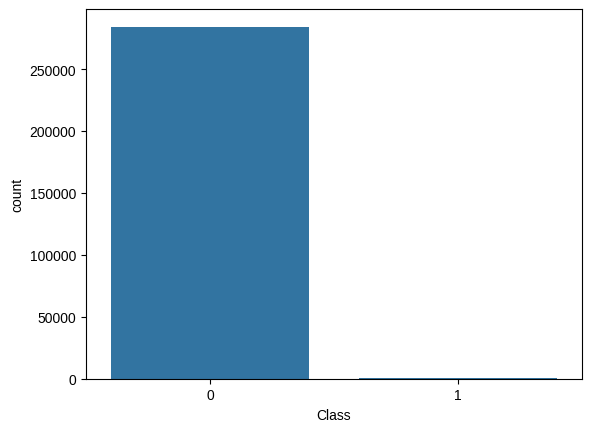

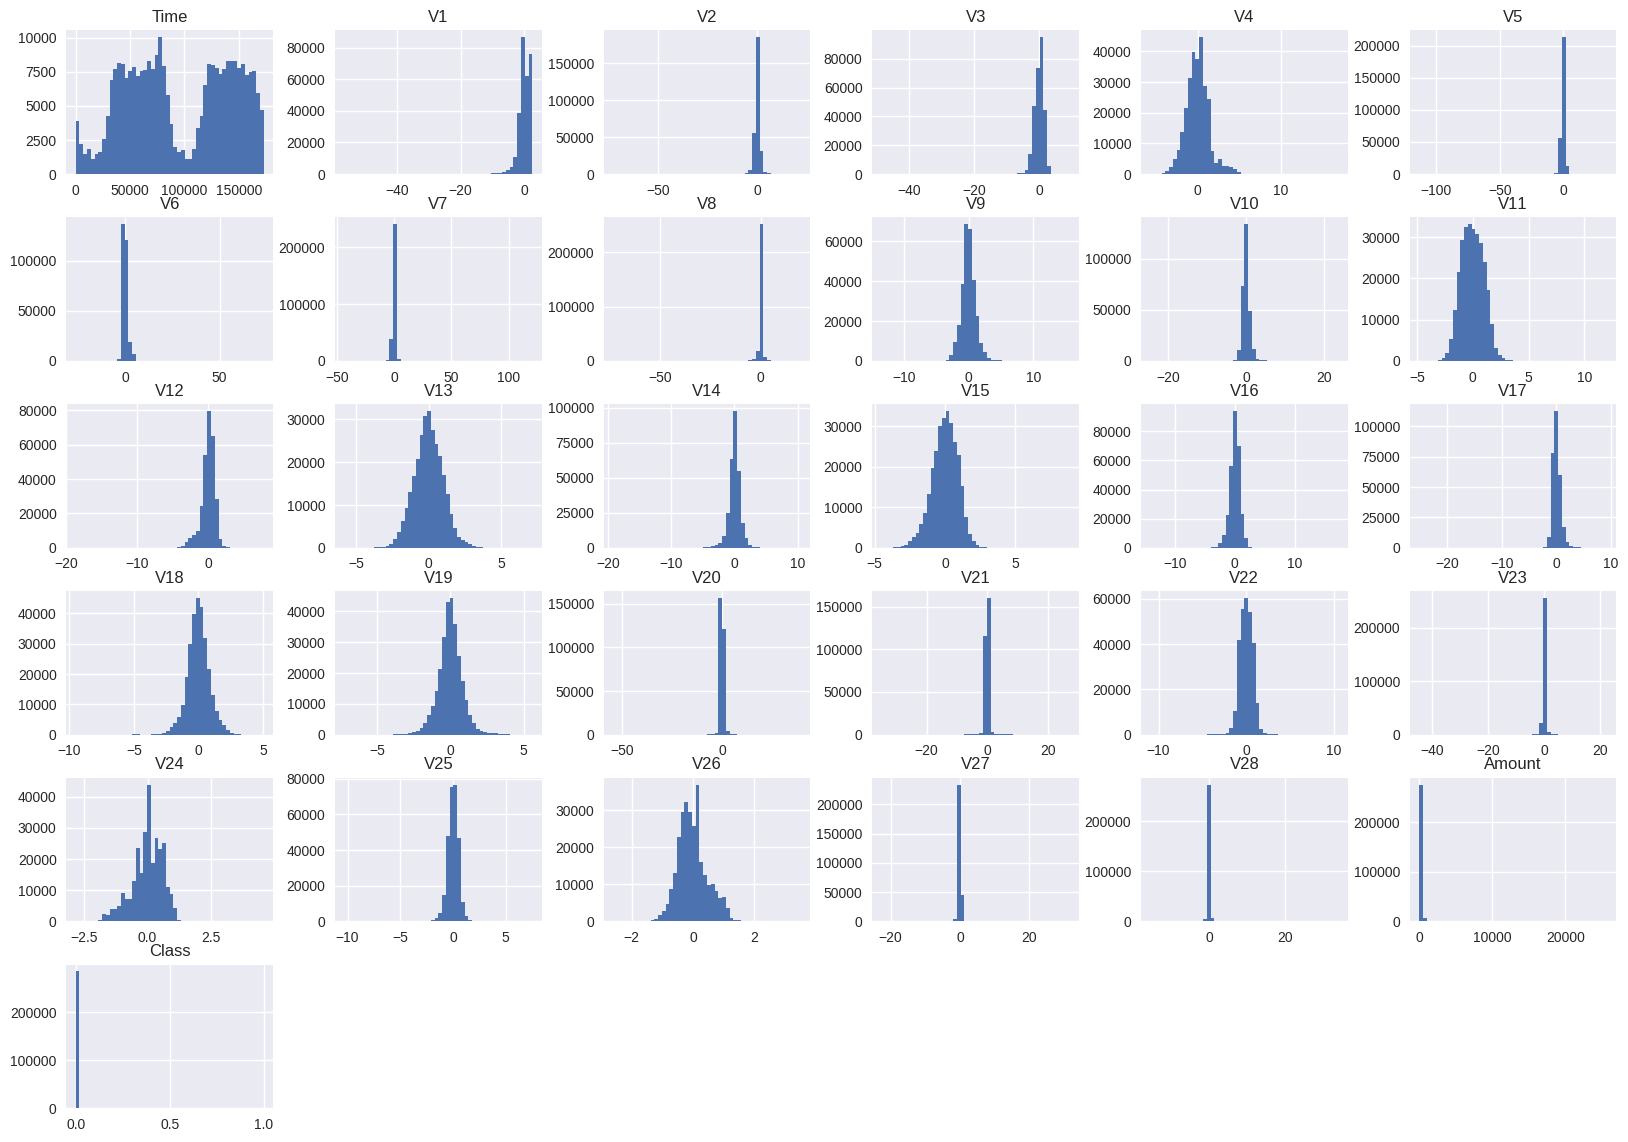

In [5]:
visualise(df)

# downsaapmle

Fitting 5 folds for each of 10 candidates, totalling 50 fits
the best params 
{'model__gamma': 'scale', 'model__class_weight': {0: 1, 1: 100}, 'model__C': 1}
the best score0.9564537680301342


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

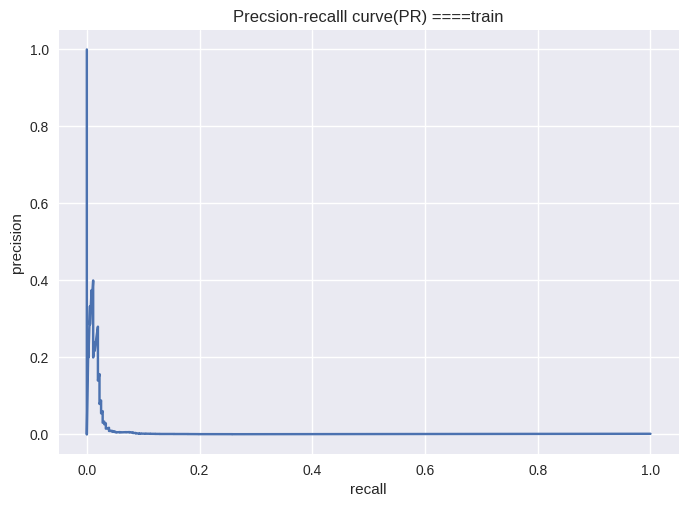

0.0015917044111278865
[[    0 85307]
 [    0   136]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     85307
           1       0.00      1.00      0.00       136

    accuracy                           0.00     85443
   macro avg       0.00      0.50      0.00     85443
weighted avg       0.00      0.00      0.00     85443



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


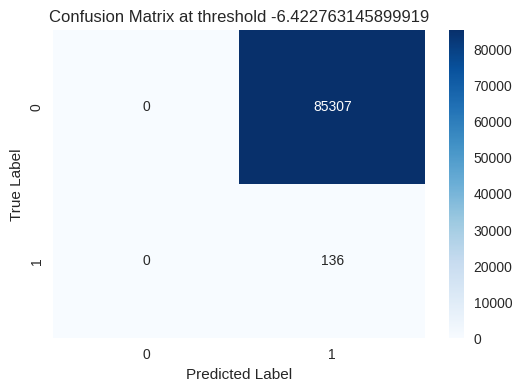

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     85307
           1       0.00      1.00      0.00       136

    accuracy                           0.00     85443
   macro avg       0.00      0.50      0.00     85443
weighted avg       0.00      0.00      0.00     85443



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


the PR_score0.09542169487909087


In [6]:
model1 = grid_with_downsampling(x_train,y_train)
threshPR1 = AUC_PR(model1,x_train,y_train)
y_pred1 = evaluate(x_test,y_test,model1,threshPR1)
#print("custom threhsold 0.2")
#y_pred11 = evaluate(x_test,y_test,l1,0.2)
y_scores1 = model1.decision_function(x_test)
precision1, recall1, thresholds = precision_recall_curve(y_test, y_scores1)
auc_score = auc(recall1, precision1)
print('the PR_score'+str(auc_score))
    




# SMOTE

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

the best score0.42372419871264155
{'model__gamma': 'scale', 'model__class_weight': {0: 1, 1: 300}, 'model__C': 1000}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

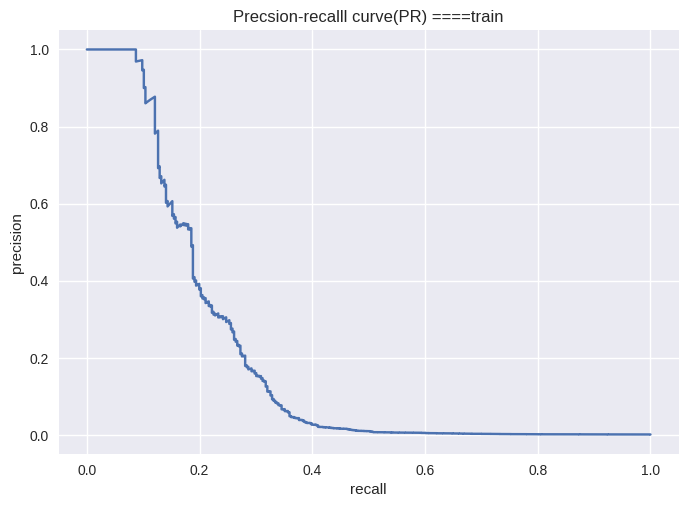

0.09685989490069404
[[ 8145 77162]
 [    5   131]]
              precision    recall  f1-score   support

           0       1.00      0.10      0.17     85307
           1       0.00      0.96      0.00       136

    accuracy                           0.10     85443
   macro avg       0.50      0.53      0.09     85443
weighted avg       1.00      0.10      0.17     85443



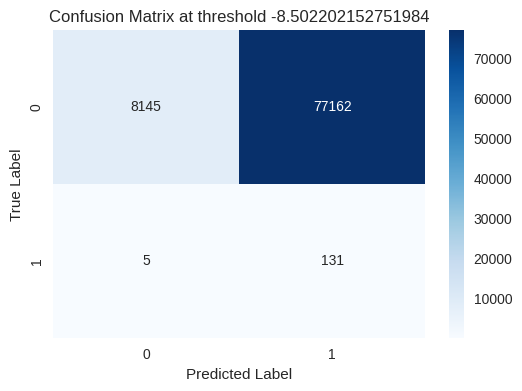

              precision    recall  f1-score   support

           0       1.00      0.10      0.17     85307
           1       0.00      0.96      0.00       136

    accuracy                           0.10     85443
   macro avg       0.50      0.53      0.09     85443
weighted avg       1.00      0.10      0.17     85443

0.19000237557028865


In [7]:
model2 = grid_with_SMOTE(x_train,y_train)
threshold2 = AUC_PR(model2,x_train,y_train)
evaluate(x_test,y_test,model2,threshold2)
y_scores = model2.decision_function(x_test)
precision2, recall2, thresholds = precision_recall_curve(y_test, y_scores)
auc_score = auc(recall2, precision2)
print(auc_score)
    

**grid with downsapmpling**

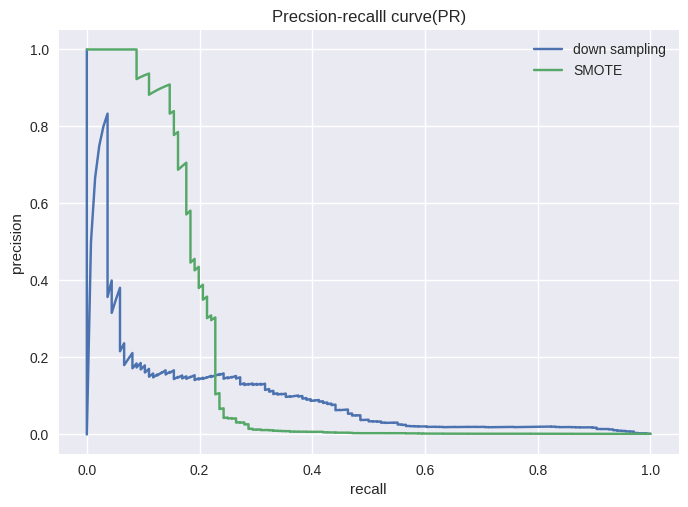

In [8]:
    plt.plot(recall1,precision1,label = "down sampling")
    plt.plot(recall2,precision2,label = "SMOTE")
    #plt.plot(recall3,precision3,label = "")
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR)")
    plt.legend()
    plt.show()